# Generating synthetic data with a Conditional GAN

In this notebook we generate the ring of 8 disk-like clusters, but in addition to the data itself, we add conditional information so that the models can try to focus on the individual clusters. In this specific case we add 2 pieces of information.

- The center of the cluster that contains a particular point
- The labeling of the cluster one-hot encoded

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from synthetic_generation.gan.models import Generator, Discriminator
from synthetic_generation.gan.training import train_gan

In [2]:
# In this version of the data generation we also return 
# n_samples length arrays with the center points and labels matching the points

def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Create distribution of disk-like clusters centered at the origin
    Parameters
    ----------
    n_samples : int
        number of data points to be created
    centers : int   
        number of clusters to have
    radius : float
        distance to origin of cluster centers
    std : float
        standard deviation of distance of points to cluster center
    seed : int
        random seed
    Returns
    -------
    tuple(np.ndarray)
        array of points, array of centers for each point, array of labels for each point
    """
    rng = np.random.default_rng(seed)

    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

#### Data Generation
We generate a random data set, and get labels and center points matching the data. The labels will be one-hot encoded and combined with the center points to form the conditional tensor.

In [3]:

# Create data and labels and points
X, c_label, c_center = make_gaussian_mixture()

In [4]:
# one hot encode the labels
one_hot = torch.nn.functional.one_hot(torch.tensor(c_label), num_classes=8).float()

In [5]:
# combine the centers and labels into one conditional vector
c = torch.cat([torch.tensor(c_center), one_hot], dim=1)

#### Model training
We create a Generator and Discriminator that use conditionals and then use the training loop to train both models

In [6]:
# set seed for reproducibility
torch.manual_seed(42)

In [ ]:
G = Generator(
    noise_dim = 2,
    num_hidden_layers = 2,
    out_dim = 2,
    hidden_dims=(128,128),
    conditional_dim=c.shape[1]
)

In [ ]:
D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128),
    conditional_dim=c.shape[1]
)

In [ ]:
train_gan(
    X=torch.tensor(X),
    G=G,
    D=D,
    c=c,
    return_history=False
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

#### Visualization
We generate a sample of synthetic data equal length to the real data and scatterplot both on the same set of axes

In [ ]:

@torch.no_grad()
def plot_samples(G, X_real,c = None, n=2000, title=None):
    """
    plot fake and real points
    Parameters
    ----------
    G: Generator
        used to create fake points
    X_real: np.ndarray
        array of real data
    c : torch.Tensor | None
        if not none , the conditional to be used
    n: int
        nmber of points to be generated
    title : str | None
        optional string to be used for title of plot
    """
    if c is not None:
        c_input = c[:n]
    else: 
        c_input = None
    X_fake = G.generate(n, c_input).cpu().numpy()
    plt.figure(figsize=(5,5))
    plt.scatter(X_real[:n,0], X_real[:n,1], s=5, alpha=0.3, label="Real")
    plt.scatter(X_fake[:,0], X_fake[:,1], s=5, alpha=0.3, label="Fake")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

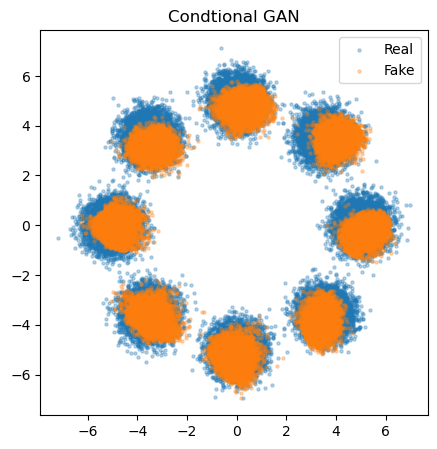

In [ ]:
plot_samples(G, X, c, len(X), "Condtional GAN")